**Notebook Criado por:** MSc. Eng. Paulo Silva  
**Notebook Criado em:** 01 / 10 / 2026  
**Última Atualização:** 02 / 10 / 2026

Obs: Este notebook foi desenvolvido sob auxílio de ferramentas de IA.

# **Condução Bidimensional em Regime Permanente**

## **Aula 03 - Solução Analítica e Diferenças Finitas**

## **Descrição do problema**

Consideramos uma placa retangular, sem geração interna de calor, em regime permanente e com propriedades constantes. Três faces são mantidas na temperatura $T_1$ e a face superior é mantida na temperatura $T_2$.

A equação governante é a equação de Laplace para a temperatura:

$$
\frac{\partial^2 T}{\partial x^2} + \frac{\partial^2 T}{\partial y^2} = 0.
$$

Para facilitar a solução analítica, usamos a temperatura adimensional:

$$
\theta = \frac{T-T_1}{T_2-T_1}.
$$

Assim, as três faces em $T_1$ passam a ter $\theta=0$ e a face superior em $T_2$ passa a ter $\theta=1$.

## **Solução analítica por separação de variáveis**

Admitindo uma solução na forma $\theta(x,y)=X(x)Y(y)$, a solução que satisfaz as condições homogêneas em $x=0$, $x=L$ e $y=0$ pode ser escrita como uma série de senos e funções hiperbólicas.

A solução analítica é dada por:

$$
\theta(x,y) = \frac{2}{\pi} \sum_{n=1}^{\infty} \frac{1-(-1)^n}{n} \sin\left(\frac{n\pi x}{L}\right) \frac{\sinh\left(\frac{n\pi y}{L}\right)}{\sinh\left(\frac{n\pi W}{L}\right)}.
$$

A temperatura é recuperada por $T=T_1+(T_2-T_1)\theta$. Na prática, a série é truncada em um número finito $N$ de termos. Como $1-(-1)^n$ é nulo para $n$ par, somente os termos ímpares contribuem.

In [1]:
# Importando bibliotecas úteis
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 5)

In [2]:
# Definindo a geometria e as temperaturas
L = 2.0       # comprimento da placa na direção x [m]
W = 1.0       # altura da placa na direção y [m]
T1 = 300.0    # temperatura nas faces x=0, x=L e y=0 [K]
T2 = 500.0    # temperatura na face y=W [K]

x_centro = L / 2
y_centro = W / 2

print(f'Ponto central: (x, y) = ({x_centro:.2f}, {y_centro:.2f}) m')
print(f'Temperaturas prescritas: T1 = {T1:.1f} K e T2 = {T2:.1f} K')

Ponto central: (x, y) = (1.00, 0.50) m
Temperaturas prescritas: T1 = 300.0 K e T2 = 500.0 K


In [3]:
def theta_analitica(x, y, n_termos):
    # Calcula a solução analítica truncada com n_termos
    theta = np.zeros_like(np.asarray(x, dtype=float))

    for n in range(1, n_termos + 1):
        coeficiente = (2 / np.pi) * (1 - (-1) ** n) / n
        theta += (
            coeficiente
            * np.sin(n * np.pi * x / L)
            * np.sinh(n * np.pi * y / L)
            / np.sinh(n * np.pi * W / L)
        )

    return theta

def temperatura_analitica(x, y, n_termos):
    theta = theta_analitica(x, y, n_termos)
    return T1 + (T2 - T1) * theta

## **Temperatura no ponto central**

A seguir, calculamos a temperatura em $(L/2,W/2)$ usando diferentes quantidades de termos da série. Essa comparação mostra diretamente como a aproximação melhora à medida que $N$ aumenta.

In [26]:
quantidades_de_termos = [1, 5, 10, 15, 20]
temperaturas_centro = []

print('Quantidade de termos | Temperatura no centro [K]')
print('--------------------|---------------------------')

for n_termos in quantidades_de_termos:
    temperatura = temperatura_analitica(x_centro, y_centro, n_termos)
    temperaturas_centro.append(float(temperatura))
    print(f'{n_termos:^20} | {float(temperatura):^25.6f}')

Quantidade de termos | Temperatura no centro [K]
--------------------|---------------------------
         1           |        396.121909        
         5           |        389.151412        
         10          |        389.026507        
         15          |        389.023000        
         20          |        389.023019        


## **Convergência da temperatura no centro**

O gráfico abaixo acompanha o valor da temperatura no centro enquanto o número de termos aumenta. Os termos pares não alteram o resultado, pois seus coeficientes são nulos.

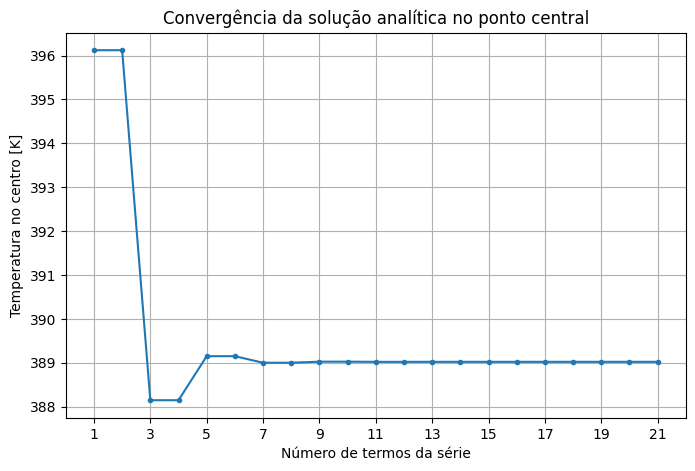

In [24]:
termos_convergencia = np.arange(1, 22)
temperaturas_convergencia = np.array([
    temperatura_analitica(x_centro, y_centro, n)
    for n in termos_convergencia
])

plt.figure(figsize=(8, 5))
plt.plot(termos_convergencia, temperaturas_convergencia, 'o-', ms=3)
plt.xticks(np.arange(1, 22, step=2))
plt.xlabel('Número de termos da série')
plt.ylabel('Temperatura no centro [K]')
plt.title('Convergência da solução analítica no ponto central')
plt.grid(True)
plt.show()

## **Campo de temperatura para diferentes quantidades de termos**

Agora visualizamos o campo de temperatura obtido com 1, 10 e 100 termos. A comparação evidencia como a série se aproxima do campo completo.

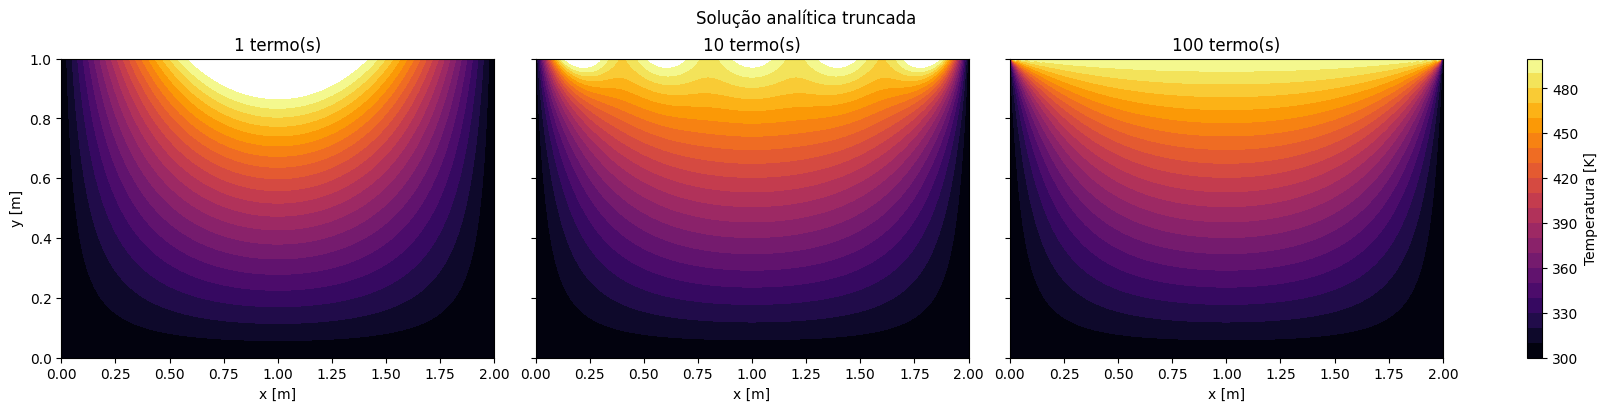

In [25]:
x_plot = np.linspace(0, L, 161)
y_plot = np.linspace(0, W, 81)
X_plot, Y_plot = np.meshgrid(x_plot, y_plot)

temperaturas_plot = {
    n: temperatura_analitica(X_plot, Y_plot, n)
    for n in [1, 10, 100]
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True, sharey=True, constrained_layout=True)
niveis = np.linspace(T1, T2, 21)

for ax, n in zip(axes, [1, 10, 100]):
    mapa = ax.contourf(X_plot, Y_plot, temperaturas_plot[n], levels=niveis, cmap='inferno')
    ax.set_title(f'{n} termo(s)')
    ax.set_xlabel('x [m]')


axes[0].set_ylabel('y [m]')
fig.colorbar(mapa, ax=axes.ravel().tolist(), label='Temperatura [K]')
fig.suptitle('Solução analítica truncada')
plt.show()

## **Solução numérica por diferenças finitas**

Dividimos a placa em uma malha regular, com pontos $x_i$ e $y_j$. Para um ponto interno, usamos a aproximação central das derivadas:

$$
\frac{\partial^2 T}{\partial x^2} \approx \frac{T_{i+1,j}-2T_{i,j}+T_{i-1,j}}{\Delta x^2},\qquad\frac{\partial^2 T}{\partial y^2} \approx \frac{T_{i,j+1}-2T_{i,j}+T_{i,j-1}}{\Delta y^2}.
$$

Substituindo na equação de Laplace, obtemos o stencil de cinco pontos:

$$
\left(\frac{2}{\Delta x^2}+\frac{2}{\Delta y^2}\right)T_{i,j}-\frac{T_{i-1,j}+T_{i+1,j}}{\Delta x^2}-\frac{T_{i,j-1}+T_{i,j+1}}{\Delta y^2}=0.
$$

As temperaturas conhecidas nas fronteiras são transferidas para o lado direito. Assim, cada ponto interno gera uma equação linear e o sistema completo é resolvido na forma $A\,T=b$.

In [7]:
# Definindo a malha de diferenças finitas
Nx = 61
Ny = 41
x_fd = np.linspace(0, L, Nx)
y_fd = np.linspace(0, W, Ny)
dx = x_fd[1] - x_fd[0]
dy = y_fd[1] - y_fd[0]

# Há (Nx-2)*(Ny-2) temperaturas desconhecidas no interior
n_internos = (Nx - 2) * (Ny - 2)
A = np.zeros((n_internos, n_internos))
b = np.zeros(n_internos)

def indice(i, j):
    # Converte o índice 2D do ponto interno em índice 1D
    return (j - 1) * (Nx - 2) + (i - 1)

coef_x = 1 / dx**2
coef_y = 1 / dy**2
coef_central = 2 * coef_x + 2 * coef_y

for j in range(1, Ny - 1):
    for i in range(1, Nx - 1):
        linha = indice(i, j)
        A[linha, linha] = coef_central

        # Vizinho à esquerda
        if i == 1:
            b[linha] += coef_x * T1
        else:
            A[linha, indice(i - 1, j)] = -coef_x

        # Vizinho à direita
        if i == Nx - 2:
            b[linha] += coef_x * T1
        else:
            A[linha, indice(i + 1, j)] = -coef_x

        # Vizinho abaixo
        if j == 1:
            b[linha] += coef_y * T1
        else:
            A[linha, indice(i, j - 1)] = -coef_y

        # Vizinho acima
        if j == Ny - 2:
            b[linha] += coef_y * T2
        else:
            A[linha, indice(i, j + 1)] = -coef_y

temperaturas_internas = np.linalg.solve(A, b)

# Reconstruindo o campo completo, incluindo as fronteiras
T_fd = np.full((Ny, Nx), T1, dtype=float)
T_fd[-1, :] = T2

for j in range(1, Ny - 1):
    for i in range(1, Nx - 1):
        T_fd[j, i] = temperaturas_internas[indice(i, j)]

X_fd, Y_fd = np.meshgrid(x_fd, y_fd)

print(f'Malha utilizada: {Nx} x {Ny} pontos')
print(f'Temperatura numérica no centro: {T_fd[Ny // 2, Nx // 2]:.6f} K')

Malha utilizada: 61 x 41 pontos
Temperatura numérica no centro: 389.004527 K


## **Visualização da solução por diferenças finitas**

O campo abaixo é a solução calculada somente a partir do sistema linear formado pelas diferenças finitas.

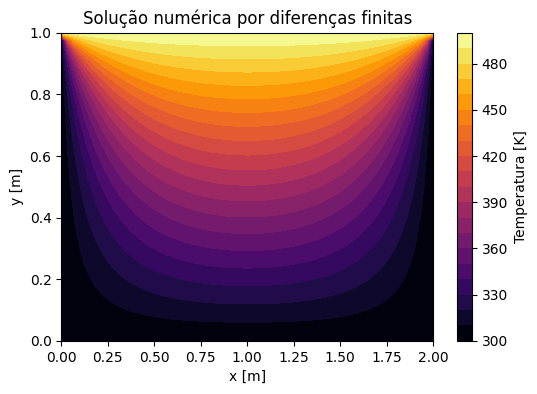

In [31]:
plt.figure(figsize=(6, 4.0))
mapa_fd = plt.contourf(X_fd, Y_fd, T_fd, levels=21, cmap='inferno')
plt.colorbar(mapa_fd, label='Temperatura [K]')
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title('Solução numérica por diferenças finitas')
#plt.gca().set_aspect('equal')
plt.show()

## **Comparação entre a solução analítica e a solução numérica**

Para a comparação, usamos a solução analítica com 100 termos. A solução numérica é obtida na malha mais grosseira definida anteriormente.

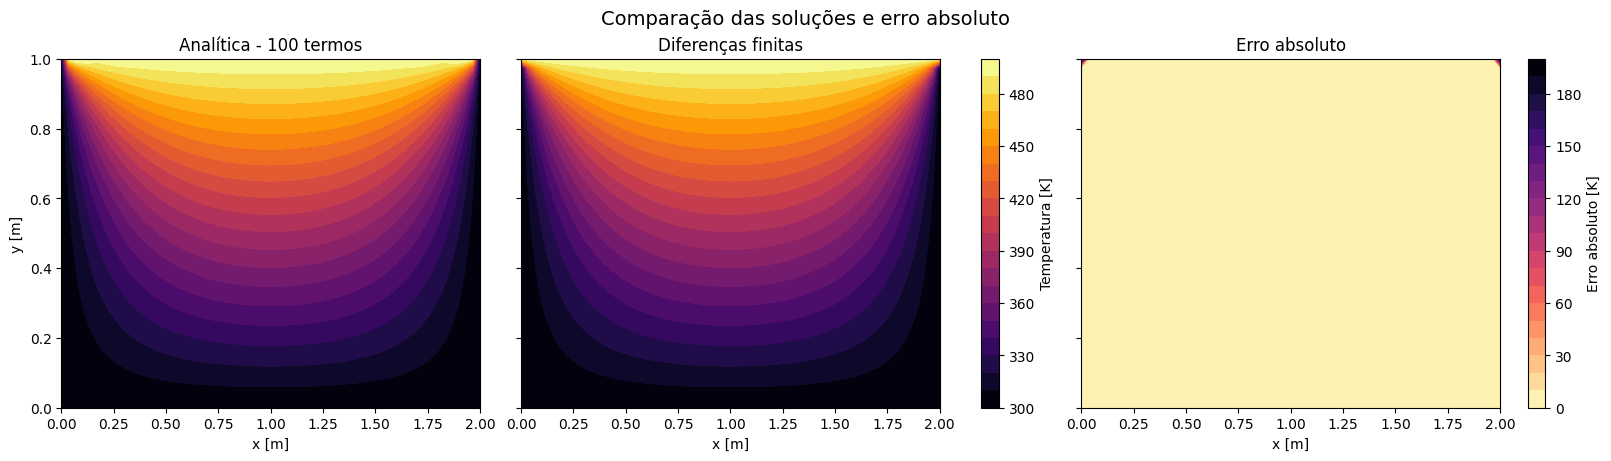

Erro máximo: 2.000000e+02 K
Erro médio: 2.367155e-01 K


In [30]:
T_analitica_ref = temperatura_analitica(X_fd, Y_fd, 100)

erro_absoluto = np.abs(
    T_analitica_ref - T_fd
)

niveis_temperatura = np.linspace(T1, T2, 21)

vmax_erro = erro_absoluto.max()
niveis_erro = np.linspace(0, vmax_erro, 21)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.5),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

# Solução analítica
mapa_analitico = axes[0].contourf(
    X_fd,
    Y_fd,
    T_analitica_ref,
    levels=niveis_temperatura,
    cmap="inferno",
    vmin=T1,
    vmax=T2,
)

axes[0].set_title("Analítica - 100 termos")

# Solução por diferenças finitas
mapa_numerico = axes[1].contourf(
    X_fd,
    Y_fd,
    T_fd,
    levels=niveis_temperatura,
    cmap="inferno",
    vmin=T1,
    vmax=T2,
)

axes[1].set_title("Diferenças finitas")

# Erro absoluto
mapa_erro = axes[2].contourf(
    X_fd,
    Y_fd,
    erro_absoluto,
    levels=niveis_erro,
    cmap="magma_r",
    vmin=0,
    vmax=vmax_erro,
)

axes[2].set_title("Erro absoluto")

for ax in axes:
    ax.set_xlabel("x [m]")
    #ax.set_aspect("equal", adjustable="box")

axes[0].set_ylabel("y [m]")

# Barra de cores da temperatura
fig.colorbar(
    mapa_numerico,
    ax=axes[:2],
    label="Temperatura [K]",
    pad=0.03,
)

# Barra de cores do erro
fig.colorbar(
    mapa_erro,
    ax=axes[2],
    label="Erro absoluto [K]",
    pad=0.03,
)

fig.suptitle(
    r"Comparação das soluções e erro absoluto",
    fontsize=14,
)

plt.show()

print(f"Erro máximo: {erro_absoluto.max():.6e} K")
print(f"Erro médio: {erro_absoluto.mean():.6e} K")